# 🧠 Neroes Adaptive Neurofeedback — EDA: User2 Multi-Session Data

**User2 dataset:** 13 sessions, 6–10 subsessions each, same hardware/protocol as user1.

**Questions answered here:**
1. Does user2 share the same 149-column schema as user1?
2. Which electrodes are active (F3/F4/C3/C4 or broader set)?
3. Is there a learning trend across 13 sessions (comparable to user1’s +0.247/ss)?
4. How does user2’s ProtocolValue distribution compare to user1’s?
5. Same AR temporal structure? Same near-random-walk delta behaviour?
6. How is the inter-subsession action distribution — still 70 % Raise?
7. Signal quality across sessions — any degraded sessions?
8. Which EEG bands are most predictive for user2?

---
> **Note on AI usage:** Claude (Anthropic) was used to scaffold this notebook structure and suggest analytical angles. All data interpretation, modelling decisions, and critical reflections are the author’s own.

## 0. Setup & Configuration

In [1]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from IPython.display import display, Markdown

warnings.filterwarnings('ignore')

# ── Paths ────────────────────────────────────────────────────────────────────
BASE_DIR  = Path('../data/raw/user2')
FIGS_DIR  = Path('../outputs/figures')
FIGS_DIR.mkdir(parents=True, exist_ok=True)

TARGET     = 'ProtocolValue'
N_SESSIONS = 13

# ── Plot style ────────────────────────────────────────────────────────────────────
NEROES_PALETTE = {
    'bg':       '#0d1117',
    'surface':  '#161b22',
    'cyan':     '#00c8ff',
    'teal':     '#00e5c3',
    'orange':   '#ff6b35',
    'yellow':   '#ffd700',
    'muted':    '#8b949e',
    'white':    '#e6edf3',
}

plt.rcParams.update({
    'figure.facecolor':  NEROES_PALETTE['bg'],
    'axes.facecolor':    NEROES_PALETTE['surface'],
    'axes.edgecolor':    NEROES_PALETTE['muted'],
    'axes.labelcolor':   NEROES_PALETTE['white'],
    'xtick.color':       NEROES_PALETTE['muted'],
    'ytick.color':       NEROES_PALETTE['muted'],
    'text.color':        NEROES_PALETTE['white'],
    'grid.color':        '#21262d',
    'grid.linestyle':    '--',
    'grid.linewidth':    0.5,
    'font.family':       'monospace',
    'axes.titlesize':    13,
    'axes.labelsize':    11,
})

SESSION_COLORS    = [plt.cm.plasma(i / max(N_SESSIONS - 1, 1)) for i in range(N_SESSIONS)]
SUBSESSION_COLORS = [NEROES_PALETTE['cyan']] + [plt.cm.plasma(i / 9) for i in range(9)]

print('✅ Setup complete.')
print(f'   Base directory : {BASE_DIR.resolve()}')
print(f'   Figures dir    : {FIGS_DIR.resolve()}')

✅ Setup complete.
   Base directory : /home/bruno1008/neroes/neroes-neurofeedback/data/raw/user2
   Figures dir    : /home/bruno1008/neroes/neroes-neurofeedback/outputs/figures


## 1. Data Loading — All 13 Sessions

In [2]:
# ── Load all 13 sessions, each with N subsessions ─────────────────────────────────
all_dfs      = []
summary_rows = []

for sess_num in range(1, N_SESSIONS + 1):
    sess_id  = f'session_{sess_num}'
    sess_dir = BASE_DIR / sess_id / 'SubSessions'

    if not sess_dir.exists():
        print(f'⚠️  {sess_id}: SubSessions dir not found — skipping')
        continue

    ss_dirs   = sorted(sess_dir.iterdir(), key=lambda x: int(x.name))
    sess_dfs  = []

    for ss_dir in ss_dirs:
        ss_id    = int(ss_dir.name)
        csv_path = ss_dir / 'Data.csv'
        if not csv_path.exists():
            continue

        df = pd.read_csv(csv_path, skiprows=8)
        df['session_id'] = sess_id       # str: 'session_1' ... 'session_13'
        df['subsession'] = ss_id         # int: 0 = baseline, 1+ = game
        sess_dfs.append(df)
        print(f'  {sess_id} / ss{ss_id:>2}: {df.shape[0]:>5,} rows')

    if not sess_dfs:
        continue

    sess_df = pd.concat(sess_dfs, ignore_index=True)
    all_dfs.append(sess_df)

    # ── Duration estimate from Timestamp column ────────────────────────────────
    try:
        ts      = pd.to_datetime(sess_df['Timestamp'], format='%m/%d/%Y %H:%M:%S')
        dur_min = (ts.max() - ts.min()).total_seconds() / 60
        dur_str = f'{dur_min:.1f} min'
    except Exception:
        dur_str = 'N/A'

    summary_rows.append({
        'session':         sess_id,
        'n_subsessions':   len(sess_dfs),
        'n_rows':          len(sess_df),
        'duration_approx': dur_str,
    })
    print()

# ── Combine ──────────────────────────────────────────────────────────────────────────
df_all = pd.concat(all_dfs, ignore_index=True)

# sample_idx: position within each (session_id, subsession) pair
df_all['sample_idx'] = df_all.groupby(['session_id', 'subsession']).cumcount().astype(int)

# session_type label
df_all['session_type'] = df_all['subsession'].apply(
    lambda x: 'Baseline (ss=0)' if x == 0 else 'Game (ss>0)'
)

print(f'Combined shape : {df_all.shape}')
print(f'Sessions loaded: {df_all["session_id"].nunique()}')
print(f'(session, ss) pairs: {df_all.groupby(["session_id", "subsession"]).ngroups}')

  session_1 / ss 0:   447 rows
  session_1 / ss 1:   240 rows
  session_1 / ss 2:   566 rows
  session_1 / ss 3:   270 rows
  session_1 / ss 4:   271 rows
  session_1 / ss 5:   270 rows
  session_1 / ss 6: 1,023 rows
  session_1 / ss 7:    45 rows

  session_2 / ss 0:   331 rows
  session_2 / ss 1: 1,155 rows
  session_2 / ss 2:   577 rows
  session_2 / ss 3:   602 rows
  session_2 / ss 4:   509 rows
  session_2 / ss 5:   566 rows

  session_3 / ss 0:   491 rows
  session_3 / ss 1:   240 rows
  session_3 / ss 2:   673 rows
  session_3 / ss 3:   526 rows
  session_3 / ss 4:   332 rows
  session_3 / ss 5:   334 rows
  session_3 / ss 6:   270 rows
  session_3 / ss 7:   401 rows
  session_3 / ss 8:   307 rows
  session_3 / ss 9:   790 rows

  session_4 / ss 0:   582 rows
  session_4 / ss 1:   248 rows
  session_4 / ss 2:   341 rows
  session_4 / ss 3:   293 rows
  session_4 / ss 4:   437 rows
  session_4 / ss 5:   491 rows
  session_4 / ss 6:   398 rows
  session_4 / ss 7:   312 rows
  ses

In [3]:
# ── Summary table ────────────────────────────────────────────────────────────────────
summary_df = pd.DataFrame(summary_rows)
print('═' * 60)
print('  MULTI-SESSION SUMMARY — USER2')
print('═' * 60)
display(summary_df)
print()
print(f'Total rows         : {df_all.shape[0]:,}')
print(f'Total sessions     : {df_all["session_id"].nunique()}')
print(f'Total (sess, ss)   : {df_all.groupby(["session_id","subsession"]).ngroups}')
print(f'Columns (total)    : {df_all.shape[1]}')
print(f'Columns (CSV-native): {df_all.shape[1] - 4}  (minus session_id, subsession, sample_idx, session_type)')

════════════════════════════════════════════════════════════
  MULTI-SESSION SUMMARY — USER2
════════════════════════════════════════════════════════════


,session,n_subsessions,n_rows,duration_approx
0,session_1,8,3132,26.2 min
1,session_2,6,3740,31.3 min
2,session_3,10,4364,36.6 min
3,session_4,10,3766,31.7 min
4,session_5,10,7589,63.8 min
5,session_6,10,4186,35.1 min
6,session_7,10,4941,41.4 min
7,session_8,10,4355,36.5 min
8,session_9,10,4131,34.7 min
9,session_10,8,5898,49.5 min



Total rows         : 58,512
Total sessions     : 13
Total (sess, ss)   : 120
Columns (total)    : 153
Columns (CSV-native): 149  (minus session_id, subsession, sample_idx, session_type)


## 2. Schema Validation

In [4]:
# ── Known user1 CSV columns (149) ───────────────────────────────────────────────────
USER1_CSV_COLS = {
    'AF3Alpha','AF3Gamma','AF3HighBeta','AF3LowBeta','AF3SignalQuality','AF3Theta',
    'AF4Alpha','AF4Gamma','AF4HighBeta','AF4LowBeta','AF4SignalQuality','AF4Theta',
    'Annotations','AsteroidPositionX','AsteroidPositionY','AudioTracks','Baseline',
    'C3Alpha','C3Gamma','C3HighBeta','C3LowBeta','C3SignalQuality','C3Theta',
    'C4Alpha','C4Gamma','C4HighBeta','C4LowBeta','C4SignalQuality','C4Theta',
    'F3Alpha','F3Gamma','F3HighBeta','F3LowBeta','F3SignalQuality','F3Theta',
    'F4Alpha','F4Gamma','F4HighBeta','F4LowBeta','F4SignalQuality','F4Theta',
    'F7Alpha','F7Gamma','F7HighBeta','F7LowBeta','F7SignalQuality','F7Theta',
    'F8Alpha','F8Gamma','F8HighBeta','F8LowBeta','F8SignalQuality','F8Theta',
    'FC5Alpha','FC5Gamma','FC5HighBeta','FC5LowBeta','FC5SignalQuality','FC5Theta',
    'FC6Alpha','FC6Gamma','FC6HighBeta','FC6LowBeta','FC6SignalQuality','FC6Theta',
    'Fp1Alpha','Fp1Gamma','Fp1HighBeta','Fp1LowBeta','Fp1SignalQuality','Fp1Theta',
    'Fp2Alpha','Fp2Gamma','Fp2HighBeta','Fp2LowBeta','Fp2SignalQuality','Fp2Theta',
    'GoodSignalQuality','LevelProgress','MaxBaseline','MaxPercentile',
    'MiddleBaseline','MiddlePercentile','MinBaseline','MinPercentile','Morale',
    'O1Alpha','O1Gamma','O1HighBeta','O1LowBeta','O1SignalQuality','O1Theta',
    'O2Alpha','O2Gamma','O2HighBeta','O2LowBeta','O2SignalQuality','O2Theta',
    'OngoingAsteroid','OngoingBlackHole','OngoingDistortedVision','OngoingRecovery',
    'OzAlpha','OzGamma','OzHighBeta','OzLowBeta','OzSignalQuality','OzTheta',
    'P7Alpha','P7Gamma','P7HighBeta','P7LowBeta','P7SignalQuality','P7Theta',
    'P8Alpha','P8Gamma','P8HighBeta','P8LowBeta','P8SignalQuality','P8Theta',
    'Percentile','PerformanceRating','PlayerPositionX','PlayerPositionY','ProtocolValue',
    'PzAlpha','PzGamma','PzHighBeta','PzLowBeta','PzSignalQuality','PzTheta',
    'RecoveryOffsetFromBaseline',
    'T7Alpha','T7Gamma','T7HighBeta','T7LowBeta','T7SignalQuality','T7Theta',
    'T8Alpha','T8Gamma','T8HighBeta','T8LowBeta','T8SignalQuality','T8Theta',
    'TangentCoefficient','Timestamp','Training','TranslationCoefficient','ValueFiltered',
}

ADDED_COLS   = {'session_id', 'subsession', 'sample_idx', 'session_type'}
u2_csv_cols  = set(df_all.columns) - ADDED_COLS

extra   = u2_csv_cols - USER1_CSV_COLS
missing = USER1_CSV_COLS - u2_csv_cols

print(f'User1 CSV columns : {len(USER1_CSV_COLS)}')
print(f'User2 CSV columns : {len(u2_csv_cols)}')
print()

if extra:
    print(f'⚠️  Extra columns in user2 (not in user1): {sorted(extra)}')
else:
    print('✅  No extra columns in user2')

if missing:
    print(f'⚠️  Missing from user2 (present in user1): {sorted(missing)}')
else:
    print('✅  No missing columns in user2')

print()
print('Per-session column consistency:')
for i in range(1, N_SESSIONS + 1):
    sid      = f'session_{i}'
    sub      = df_all[df_all['session_id'] == sid]
    if sub.empty: continue
    sc       = set(sub.columns) - ADDED_COLS
    drift    = sc.symmetric_difference(u2_csv_cols)
    mark     = '✅' if not drift else '⚠️'
    extra_s  = sc - u2_csv_cols
    miss_s   = u2_csv_cols - sc
    note     = ''
    if extra_s:  note += f' extra: {extra_s}'
    if miss_s:   note += f' missing: {miss_s}'
    print(f'  {sid}: {mark}{note}')

User1 CSV columns : 149
User2 CSV columns : 149

✅  No extra columns in user2
✅  No missing columns in user2

Per-session column consistency:
  session_1: ✅
  session_2: ✅
  session_3: ✅
  session_4: ✅
  session_5: ✅
  session_6: ✅
  session_7: ✅
  session_8: ✅
  session_9: ✅
  session_10: ✅
  session_11: ✅
  session_12: ✅
  session_13: ✅


In [5]:
# ── Active electrodes: which sites have non-zero signal? ────────────────────────────
ELECTRODES = ['AF3','AF4','C3','C4','F3','F4','F7','F8','FC5','FC6',
              'Fp1','Fp2','O1','O2','Oz','P7','P8','Pz','T7','T8']
BANDS      = ['Alpha','HighBeta','LowBeta','Theta','Gamma']

active_summary = []
for elec in ELECTRODES:
    band_cols  = [f'{elec}{b}' for b in BANDS if f'{elec}{b}' in df_all.columns]
    sq_col     = f'{elec}SignalQuality'
    mean_sq    = df_all[sq_col].mean() if sq_col in df_all.columns else 0.0
    any_nonzero = any(df_all[c].abs().sum() > 0 for c in band_cols)
    active_summary.append({'electrode': elec,
                           'active': any_nonzero,
                           'mean_signal_quality': round(mean_sq, 4),
                           'n_band_cols': len(band_cols)})

act_df = pd.DataFrame(active_summary)
print('Electrode activity in user2:')
display(act_df)

active_elecs = act_df[act_df['active']]['electrode'].tolist()
print(f'\nActive electrodes ({len(active_elecs)}): {active_elecs}')
print()
# User1 reference: only F3, F4, C3, C4 were active
USER1_ACTIVE = ['F3','F4','C3','C4']
added_elecs   = [e for e in active_elecs if e not in USER1_ACTIVE]
removed_elecs = [e for e in USER1_ACTIVE if e not in active_elecs]
if added_elecs:   print(f'↑ User2 has MORE active electrodes vs user1: {added_elecs}')
if removed_elecs: print(f'↓ User2 is MISSING these user1 electrodes: {removed_elecs}')
if not added_elecs and not removed_elecs:
    print('✅  Identical active electrode set as user1 (F3, F4, C3, C4)')

Electrode activity in user2:


,electrode,active,mean_signal_quality,n_band_cols
0,AF3,False,0.0000,5
1,AF4,False,0.0000,5
2,C3,True,3.6790,5
3,C4,True,3.9181,5
4,F3,True,3.9107,5
5,F4,True,3.9145,5
6,F7,False,0.0000,5
7,F8,False,0.0000,5
8,FC5,False,0.0000,5
9,FC6,False,0.0000,5



Active electrodes (8): ['C3', 'C4', 'F3', 'F4', 'Fp1', 'Fp2', 'Oz', 'Pz']

↑ User2 has MORE active electrodes vs user1: ['Fp1', 'Fp2', 'Oz', 'Pz']


In [6]:
# ── Signal quality column overview ──────────────────────────────────────────────────────
SQ_COLS = [c for c in df_all.columns if 'SignalQuality' in c]
print(f'Signal quality columns ({len(SQ_COLS)}):')
sq_stats = df_all[SQ_COLS].describe(percentiles=[.1,.5,.9]).T.round(4)
display(sq_stats)

# GoodSignalQuality boolean summary
if 'GoodSignalQuality' in df_all.columns:
    gsq = df_all['GoodSignalQuality']
    print(f'\nGoodSignalQuality overall: {gsq.mean():.2%} True ({gsq.sum():,} / {len(gsq):,} rows)')

Signal quality columns (21):


,count,mean,std,min,10%,50%,90%,max
AF3SignalQuality,58512.0,0.0000,0.0000,0.0,0.0,0.0,0.0,0.0
AF4SignalQuality,58512.0,0.0000,0.0000,0.0,0.0,0.0,0.0,0.0
C3SignalQuality,58512.0,3.6790,0.9223,0.0,3.0,4.0,4.0,4.0
C4SignalQuality,58512.0,3.9181,0.4812,0.0,4.0,4.0,4.0,4.0
F3SignalQuality,58512.0,3.9107,0.5113,0.0,4.0,4.0,4.0,4.0
F4SignalQuality,58512.0,3.9145,0.5001,0.0,4.0,4.0,4.0,4.0
F7SignalQuality,58512.0,0.0000,0.0000,0.0,0.0,0.0,0.0,0.0
F8SignalQuality,58512.0,0.0000,0.0000,0.0,0.0,0.0,0.0,0.0
FC5SignalQuality,58512.0,0.0000,0.0000,0.0,0.0,0.0,0.0,0.0
FC6SignalQuality,58512.0,0.0000,0.0000,0.0,0.0,0.0,0.0,0.0



GoodSignalQuality overall: 95.49% True (55,875 / 58,512 rows)


## 3. ProtocolValue Analysis — Per Session

In [7]:
# ── Stats table: mean/std/min/max per session (game subsessions only) ─────────────────
game_df   = df_all[df_all['subsession'] > 0].copy()
ss0_df    = df_all[df_all['subsession'] == 0].copy()

pv_session_stats = (
    game_df.groupby('session_id')[TARGET]
    .agg(['mean','std','min','max','count'])
    .round(4)
    .reset_index()
)
pv_session_stats.columns = ['session','mean_pv','std_pv','min_pv','max_pv','n_rows']
pv_session_stats['session_num'] = pv_session_stats['session'].str.extract(r'(\d+)').astype(int)
pv_session_stats = pv_session_stats.sort_values('session_num').reset_index(drop=True)

print('═' * 70)
print('  ProtocolValue Stats per Session (game subsessions, ss > 0)')
print('═' * 70)
display(pv_session_stats)

# ── Linear trend: is there a learning signal across sessions? ────────────────────
from scipy.stats import linregress

slope, intercept, r, p, se = linregress(
    pv_session_stats['session_num'], pv_session_stats['mean_pv']
)
print(f'\nLinear trend across sessions (mean PV vs session number):')
print(f'  Slope     : {slope:+.4f}  (vs user1 within-session: +0.247/subsession)')
print(f'  Intercept : {intercept:.4f}')
print(f'  R²        : {r**2:.4f}')
print(f'  p-value   : {p:.4f}')
if p < 0.05:
    direction = 'IMPROVING' if slope > 0 else 'DECLINING'
    print(f'  → Statistically significant {direction} trend across sessions (p < 0.05)')
else:
    print('  → No statistically significant trend (p ≥ 0.05) — flat or noisy')

══════════════════════════════════════════════════════════════════════
  ProtocolValue Stats per Session (game subsessions, ss > 0)
══════════════════════════════════════════════════════════════════════


,session,mean_pv,std_pv,min_pv,max_pv,n_rows,session_num
0,session_1,0.0046,0.3959,-1.8875,2.0499,2685,1
1,session_2,0.0253,0.2679,-1.4168,1.7378,3409,2
2,session_3,0.0745,0.5064,-2.1386,1.8918,3873,3
3,session_4,-0.0192,0.4504,-2.4555,2.2302,3184,4
4,session_5,0.0865,0.5002,-2.0605,2.1973,7121,5
5,session_6,-0.0121,0.4368,-1.9499,1.8141,3741,6
6,session_7,0.0803,0.5342,-2.2677,2.5979,4472,7
7,session_8,0.0275,0.4119,-2.0412,2.2758,3865,8
8,session_9,-0.3142,0.6101,-2.6483,2.5085,3639,9
9,session_10,-0.0070,0.4707,-2.3205,2.3169,5392,10



Linear trend across sessions (mean PV vs session number):
  Slope     : -0.0085  (vs user1 within-session: +0.247/subsession)
  Intercept : 0.0511
  R²        : 0.1066
  p-value   : 0.2762
  → No statistically significant trend (p ≥ 0.05) — flat or noisy


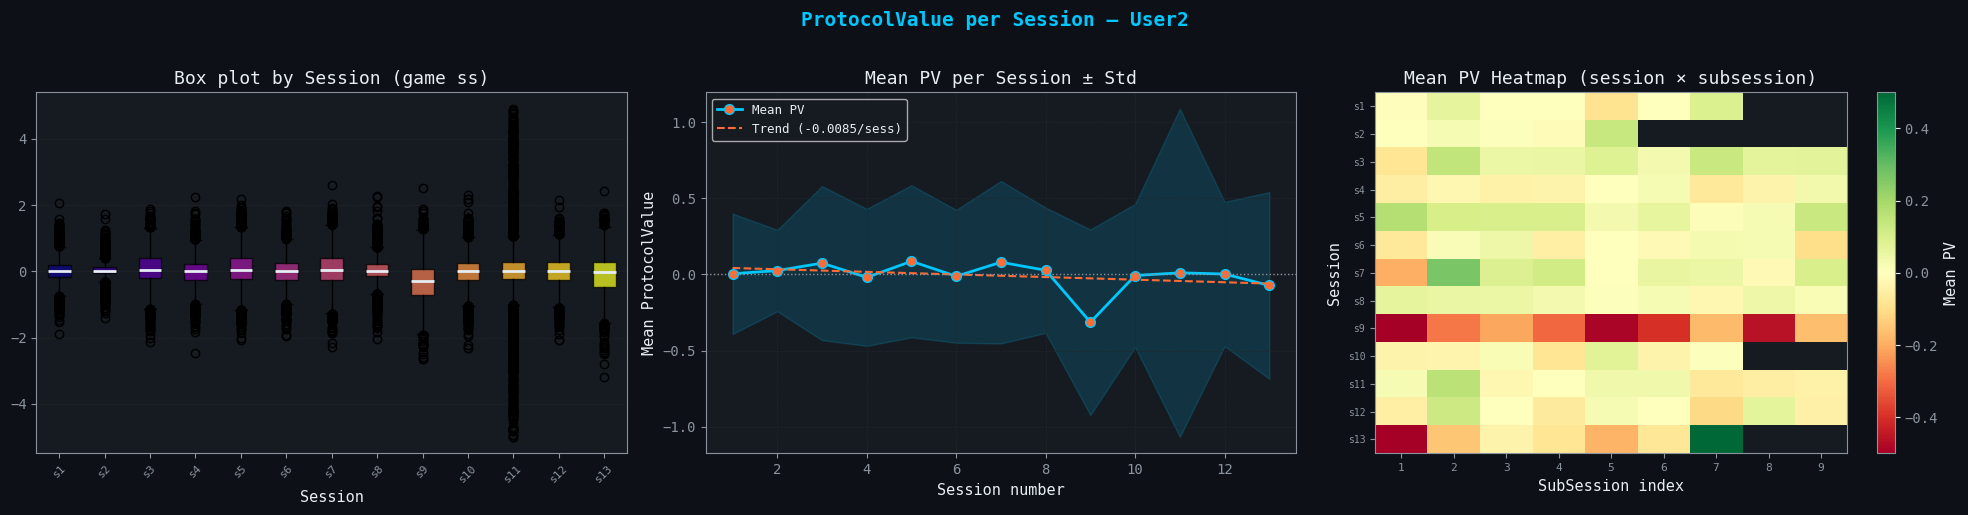

💾 Saved: outputs/figures/u2_pv_per_session.png


In [8]:
# ── Distribution of ProtocolValue per session + mean-per-session line chart ─────────
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('ProtocolValue per Session — User2', fontsize=14,
             color=NEROES_PALETTE['cyan'], fontweight='bold', y=1.02)

# ---- Box plot per session -----------------------------------------------
data_by_sess = [
    game_df[game_df['session_id'] == f'session_{i}'][TARGET].dropna().values
    for i in range(1, N_SESSIONS + 1)
]
bp = axes[0].boxplot(data_by_sess, patch_artist=True, notch=False,
                     medianprops=dict(color=NEROES_PALETTE['white'], lw=2))
for i, patch in enumerate(bp['boxes']):
    patch.set_facecolor(SESSION_COLORS[i])
    patch.set_alpha(0.75)
axes[0].set_xticklabels([f's{i}' for i in range(1, N_SESSIONS + 1)], rotation=45, fontsize=8)
axes[0].set_xlabel('Session')
axes[0].set_title('Box plot by Session (game ss)')
axes[0].grid(True, axis='y')

# ---- Mean PV per session (line chart with trend) ------------------------
xs = pv_session_stats['session_num'].values
ys = pv_session_stats['mean_pv'].values
axes[1].plot(xs, ys, color=NEROES_PALETTE['cyan'], lw=2, marker='o',
             markerfacecolor=NEROES_PALETTE['orange'], markersize=7, label='Mean PV')
axes[1].fill_between(xs,
                     ys - pv_session_stats['std_pv'].values,
                     ys + pv_session_stats['std_pv'].values,
                     alpha=0.15, color=NEROES_PALETTE['cyan'])
# Trend line
trend_y = slope * xs + intercept
axes[1].plot(xs, trend_y, color=NEROES_PALETTE['orange'], lw=1.5,
             linestyle='--', label=f'Trend ({slope:+.4f}/sess)')
axes[1].axhline(0, color=NEROES_PALETTE['muted'], lw=1, linestyle=':')
axes[1].set_xlabel('Session number')
axes[1].set_ylabel('Mean ProtocolValue')
axes[1].set_title('Mean PV per Session ± Std')
axes[1].legend(fontsize=9)
axes[1].grid(True)

# ---- Per-session subsession trajectory heatmap --------------------------
pv_heatmap_rows = []
for i in range(1, N_SESSIONS + 1):
    sess_id = f'session_{i}'
    ss_stats = (
        df_all[(df_all['session_id'] == sess_id) & (df_all['subsession'] > 0)]
        .groupby('subsession')[TARGET].mean()
    )
    pv_heatmap_rows.append(ss_stats)
heat_df = pd.DataFrame(pv_heatmap_rows,
                        index=[f's{i}' for i in range(1, N_SESSIONS + 1)])
nim = axes[2].imshow(heat_df.values, aspect='auto', cmap='RdYlGn',
                     vmin=-0.5, vmax=0.5, interpolation='nearest')
cbar = fig.colorbar(nim, ax=axes[2])
cbar.set_label('Mean PV', color=NEROES_PALETTE['white'])
cbar.ax.yaxis.set_tick_params(color=NEROES_PALETTE['white'])
axes[2].set_xlabel('SubSession index')
axes[2].set_ylabel('Session')
axes[2].set_title('Mean PV Heatmap (session × subsession)')
axes[2].set_yticks(range(N_SESSIONS))
axes[2].set_yticklabels([f's{i}' for i in range(1, N_SESSIONS + 1)], fontsize=7)
axes[2].set_xticks(range(heat_df.shape[1]))
axes[2].set_xticklabels([str(c) for c in heat_df.columns], fontsize=8)

plt.tight_layout()
plt.savefig(FIGS_DIR / 'u2_pv_per_session.png', dpi=150,
            bbox_inches='tight', facecolor=NEROES_PALETTE['bg'])
plt.show()
print('💾 Saved: outputs/figures/u2_pv_per_session.png')

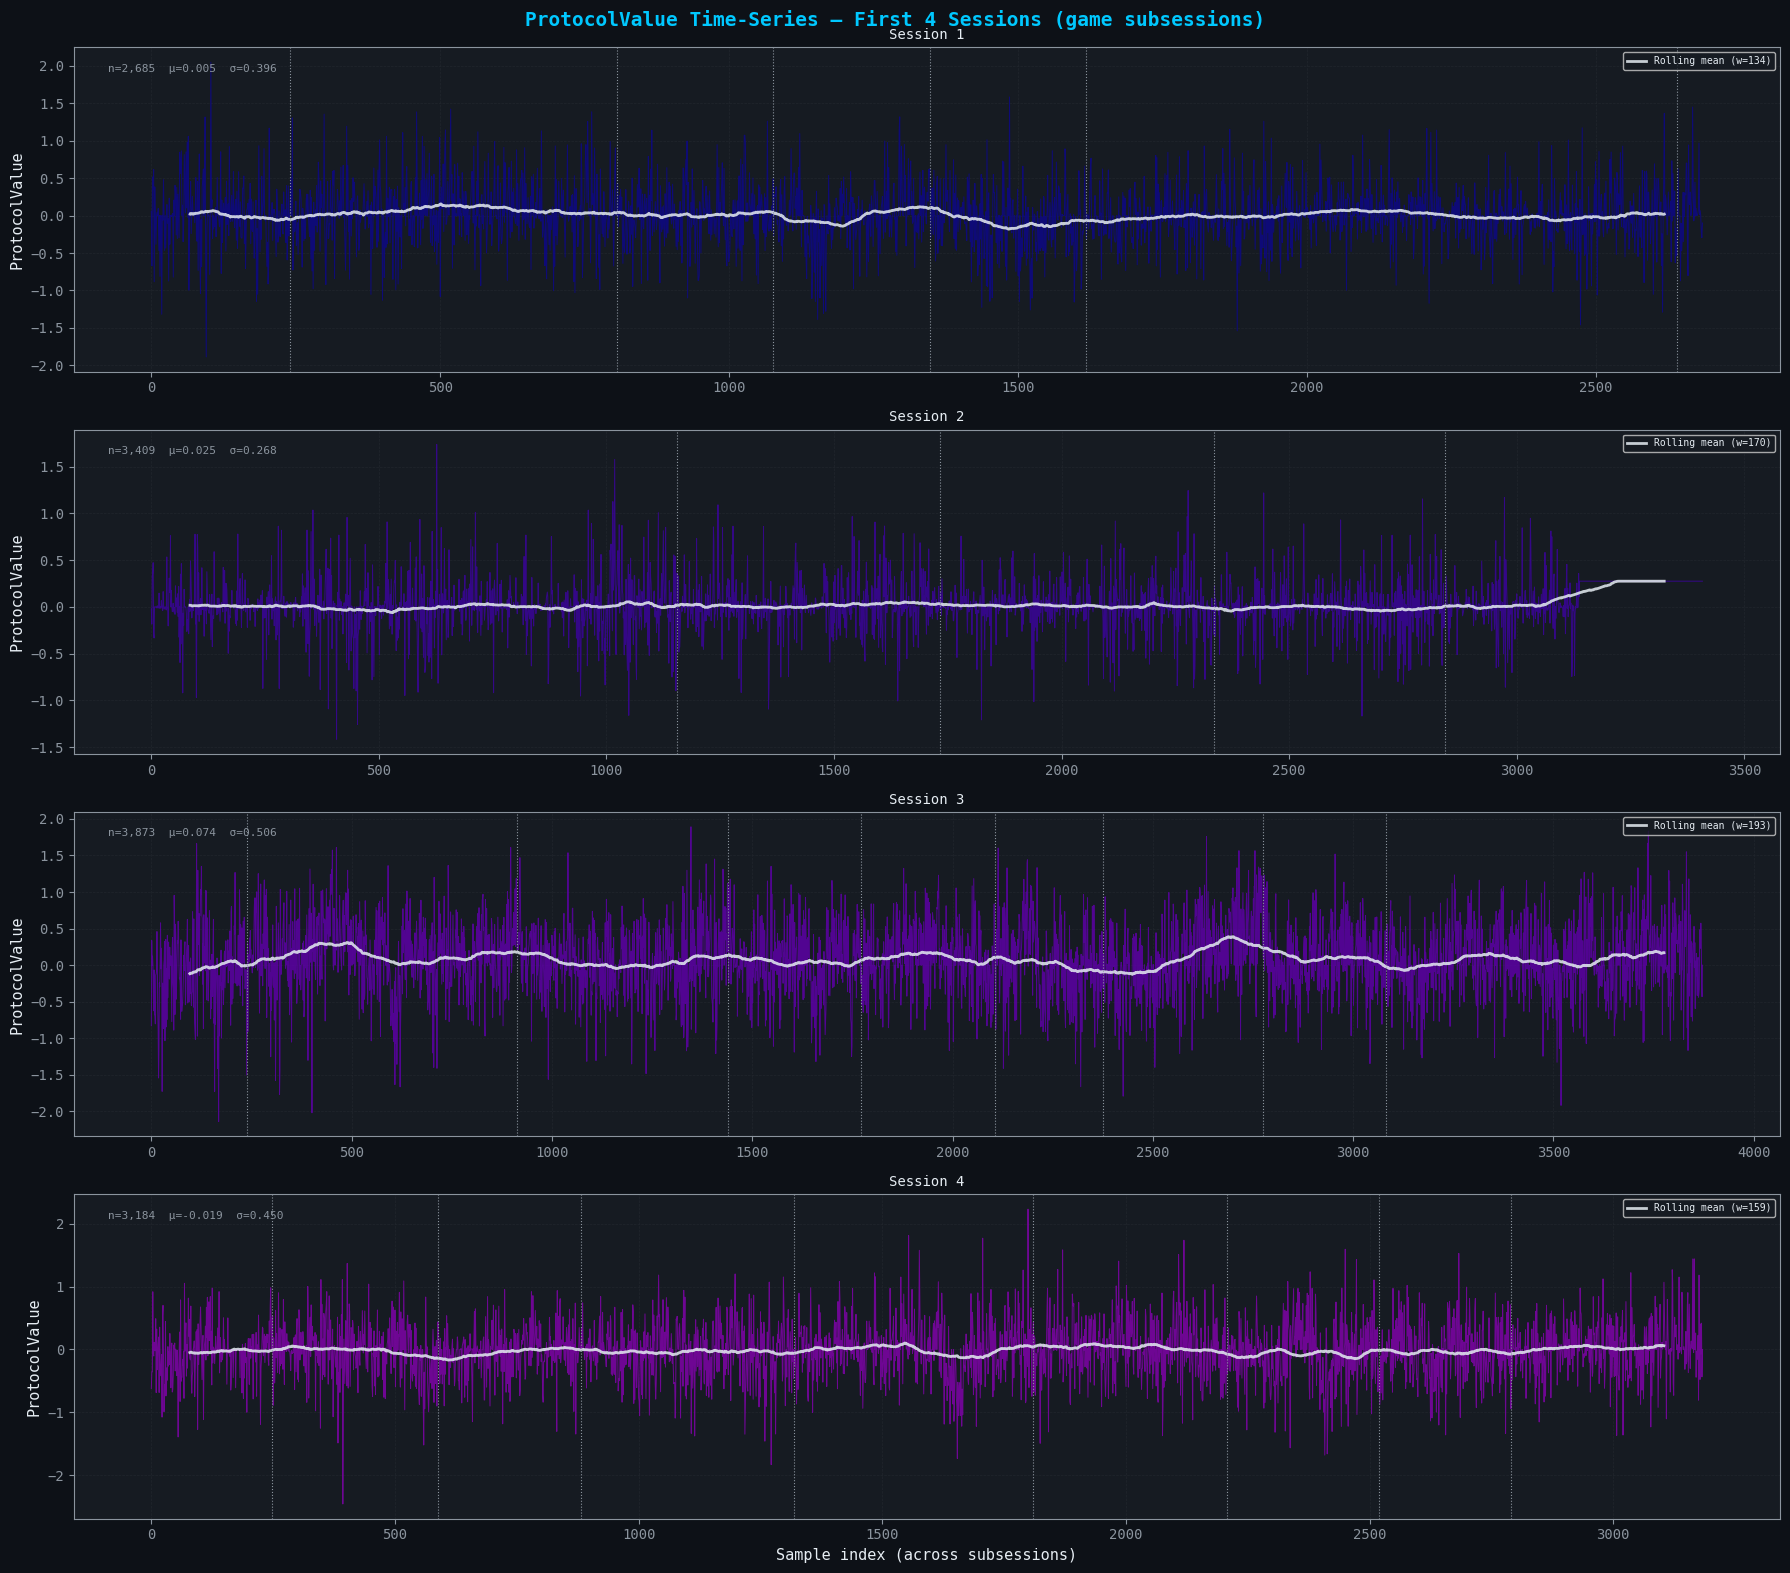

💾 Saved: outputs/figures/u2_pv_timeseries.png


In [9]:
# ── Time-series plot: first 4 sessions (ss > 0 concatenated within session) ──────────
SHOW_SESSIONS = min(4, N_SESSIONS)
fig, axes = plt.subplots(SHOW_SESSIONS, 1, figsize=(18, 4 * SHOW_SESSIONS))
fig.suptitle('ProtocolValue Time-Series — First 4 Sessions (game subsessions)',
             fontsize=14, color=NEROES_PALETTE['cyan'], fontweight='bold')

for idx, sess_num in enumerate(range(1, SHOW_SESSIONS + 1)):
    sess_id = f'session_{sess_num}'
    ax      = axes[idx]
    color   = SESSION_COLORS[sess_num - 1]

    sub = df_all[(df_all['session_id'] == sess_id) & (df_all['subsession'] > 0)].copy()
    sub = sub.sort_values(['subsession', 'sample_idx'])
    xs  = np.arange(len(sub))

    ax.plot(xs, sub[TARGET].values, color=color, lw=0.7, alpha=0.85)

    # rolling mean
    window = max(10, len(sub) // 20)
    roll   = sub[TARGET].rolling(window, center=True).mean()
    ax.plot(xs, roll.values, color=NEROES_PALETTE['white'], lw=2.0, alpha=0.85,
            label=f'Rolling mean (w={window})')

    # vertical lines at subsession boundaries
    ss_boundaries = sub.groupby('subsession')['sample_idx'].count().cumsum().values[:-1]
    offset = 0
    for j, bd in enumerate(sub['subsession'].unique()[:-1]):
        offset += sub[sub['subsession'] == bd].shape[0]
        ax.axvline(offset, color=NEROES_PALETTE['muted'], lw=0.8, linestyle=':')

    ax.set_title(f'Session {sess_num}', fontsize=10)
    ax.set_ylabel('ProtocolValue')
    ax.legend(fontsize=7, loc='upper right')
    ax.grid(True)
    ax.text(0.02, 0.95,
            f'n={len(sub):,}  \u03bc={sub[TARGET].mean():.3f}  \u03c3={sub[TARGET].std():.3f}',
            transform=ax.transAxes, fontsize=8,
            color=NEROES_PALETTE['muted'], va='top')

axes[-1].set_xlabel('Sample index (across subsessions)')
plt.tight_layout()
plt.savefig(FIGS_DIR / 'u2_pv_timeseries.png', dpi=150,
            bbox_inches='tight', facecolor=NEROES_PALETTE['bg'])
plt.show()
print('💾 Saved: outputs/figures/u2_pv_timeseries.png')

## 4. User1 vs User2 Comparison

In [10]:
# ── Load user1 processed data ──────────────────────────────────────────────────────────
u1_path = Path('../data/processed/processed_data.parquet')
if u1_path.exists():
    df_u1 = pd.read_parquet(u1_path)
    print(f'User1 data loaded: {df_u1.shape}')
    print(f'  Baseline rows (ss=0): {(df_u1["subsession"]==0).sum():,}')
    print(f'  Game rows (ss>0):     {(df_u1["subsession"]>0).sum():,}')
    u1_loaded = True
else:
    print(f'⚠️  {u1_path} not found — run 01_eda.ipynb first to generate it.')
    u1_loaded = False

User1 data loaded: (3549, 157)
  Baseline rows (ss=0): 837
  Game rows (ss>0):     2,712


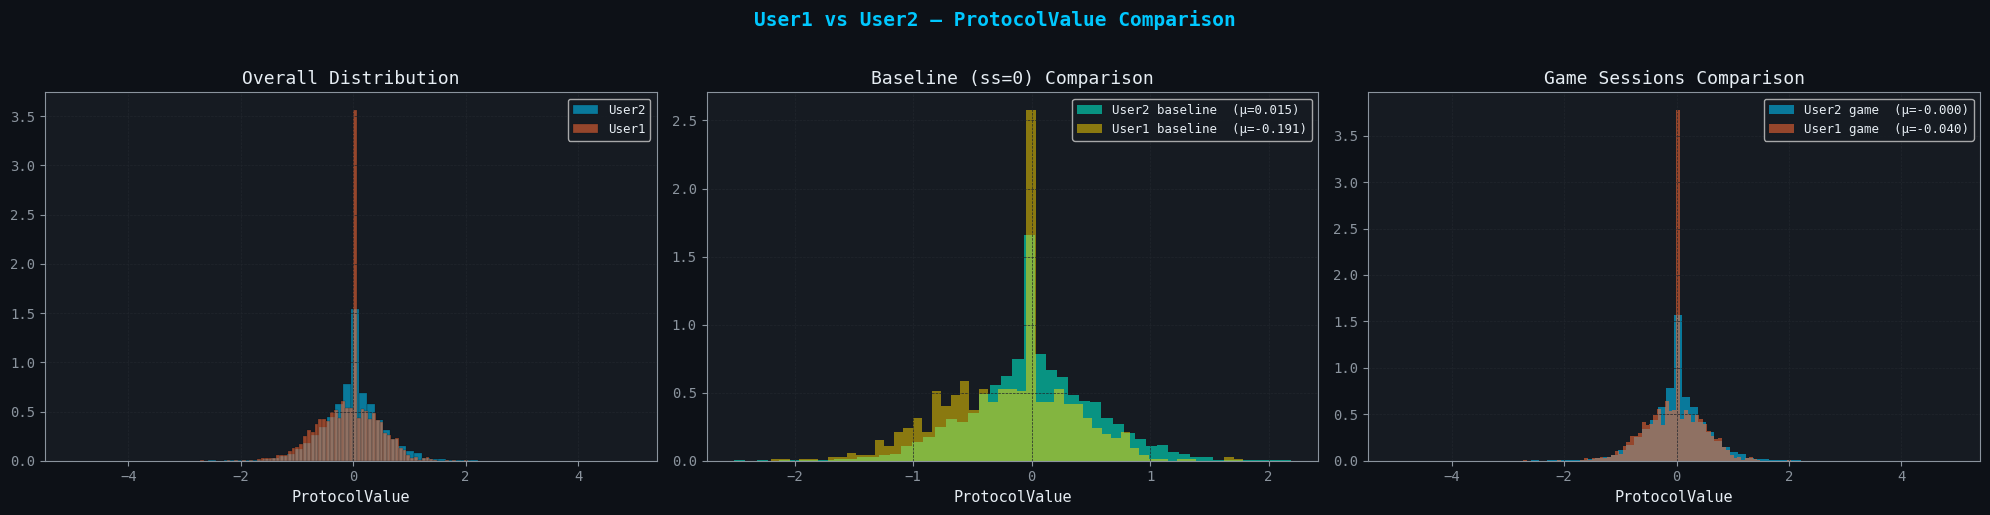

💾 Saved: outputs/figures/u2_comparison_distributions.png


In [11]:
# ── Side-by-side ProtocolValue distributions ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('User1 vs User2 — ProtocolValue Comparison', fontsize=14,
             color=NEROES_PALETTE['cyan'], fontweight='bold', y=1.02)

# ---- Overall distribution -----------------------------------------------
u2_pv = df_all[TARGET].dropna()
axes[0].hist(u2_pv, bins=70, color=NEROES_PALETTE['cyan'], alpha=0.55,
             edgecolor=NEROES_PALETTE['bg'], linewidth=0.3, label='User2', density=True)
if u1_loaded:
    u1_pv = df_u1[TARGET].dropna()
    axes[0].hist(u1_pv, bins=70, color=NEROES_PALETTE['orange'], alpha=0.55,
                 edgecolor=NEROES_PALETTE['bg'], linewidth=0.3, label='User1', density=True)
axes[0].set_xlabel('ProtocolValue')
axes[0].set_title('Overall Distribution')
axes[0].legend(fontsize=9)
axes[0].grid(True)

# ---- Baseline (ss=0) comparison -----------------------------------------
u2_ss0 = df_all[df_all['subsession'] == 0][TARGET].dropna()
axes[1].hist(u2_ss0, bins=50, color=NEROES_PALETTE['teal'], alpha=0.6,
             label=f'User2 baseline  (\u03bc={u2_ss0.mean():.3f})', density=True)
if u1_loaded:
    u1_ss0 = df_u1[df_u1['subsession'] == 0][TARGET].dropna()
    axes[1].hist(u1_ss0, bins=50, color=NEROES_PALETTE['yellow'], alpha=0.5,
                 label=f'User1 baseline  (\u03bc={u1_ss0.mean():.3f})', density=True)
axes[1].set_xlabel('ProtocolValue')
axes[1].set_title('Baseline (ss=0) Comparison')
axes[1].legend(fontsize=9)
axes[1].grid(True)

# ---- Game sessions comparison -------------------------------------------
u2_game = df_all[df_all['subsession'] > 0][TARGET].dropna()
axes[2].hist(u2_game, bins=70, color=NEROES_PALETTE['cyan'], alpha=0.55,
             label=f'User2 game  (\u03bc={u2_game.mean():.3f})', density=True)
if u1_loaded:
    u1_game = df_u1[df_u1['subsession'] > 0][TARGET].dropna()
    axes[2].hist(u1_game, bins=70, color=NEROES_PALETTE['orange'], alpha=0.55,
                 label=f'User1 game  (\u03bc={u1_game.mean():.3f})', density=True)
axes[2].set_xlabel('ProtocolValue')
axes[2].set_title('Game Sessions Comparison')
axes[2].legend(fontsize=9)
axes[2].grid(True)

plt.tight_layout()
plt.savefig(FIGS_DIR / 'u2_comparison_distributions.png', dpi=150,
            bbox_inches='tight', facecolor=NEROES_PALETTE['bg'])
plt.show()
print('💾 Saved: outputs/figures/u2_comparison_distributions.png')

In [12]:
# ── TangentCoefficient and TranslationCoefficient comparison ──────────────────────
u2_game_df = df_all[df_all['subsession'] > 0]

for col in ['TangentCoefficient', 'TranslationCoefficient']:
    u2_vals = u2_game_df[col].dropna()
    print(f'{col}:')
    print(f'  User2 \u2014 mean={u2_vals.mean():.5f}  std={u2_vals.std():.5f}  '
          f'min={u2_vals.min():.5f}  max={u2_vals.max():.5f}  nunique={u2_vals.nunique()}')
    if u1_loaded and col in df_u1.columns:
        u1_vals = df_u1[df_u1['subsession'] > 0][col].dropna()
        print(f'  User1 \u2014 mean={u1_vals.mean():.5f}  std={u1_vals.std():.5f}  '
              f'min={u1_vals.min():.5f}  max={u1_vals.max():.5f}  nunique={u1_vals.nunique()}')
        same = np.isclose(u2_vals.mean(), u1_vals.mean(), atol=0.05)
        match_str = '\u2705 similar' if same else '\u26a0\ufe0f  different'
        print(f'  Match: {match_str}')
    print()

# ── Per-session summary of calibration params (user2) ───────────────────────────
calib_df = (
    u2_game_df.groupby('session_id')[['TangentCoefficient', 'TranslationCoefficient']]
    .mean().round(5)
    .reset_index()
)
calib_df['session_num'] = calib_df['session_id'].str.extract(r'(\d+)').astype(int)
calib_df = calib_df.sort_values('session_num').drop('session_num', axis=1)
print('Calibration parameters per session (user2, game ss mean):')
display(calib_df)

TangentCoefficient:
  User2 — mean=4.23319  std=0.05288  min=4.20445  max=4.41429  nunique=5
  User1 — mean=4.41429  std=0.00000  min=4.41429  max=4.41429  nunique=1
  Match: ⚠️  different

TranslationCoefficient:
  User2 — mean=-0.00276  std=0.05151  min=-0.07622  max=0.09429  nunique=5
  User1 — mean=-0.07622  std=0.00000  min=-0.07622  max=-0.07622  nunique=1
  Match: ⚠️  different

Calibration parameters per session (user2, game ss mean):


,session_id,TangentCoefficient,TranslationCoefficient
0,session_1,4.41429,-0.07622
5,session_2,4.23851,0.00000
6,session_3,4.20452,-0.04336
7,session_4,4.30006,0.09429
8,session_5,4.20445,0.04336
9,session_6,4.20452,-0.04336
10,session_7,4.20452,-0.04336
11,session_8,4.20452,-0.04336
12,session_9,4.20452,-0.04336
1,session_10,4.23851,0.00000


## 5. Temporal Structure

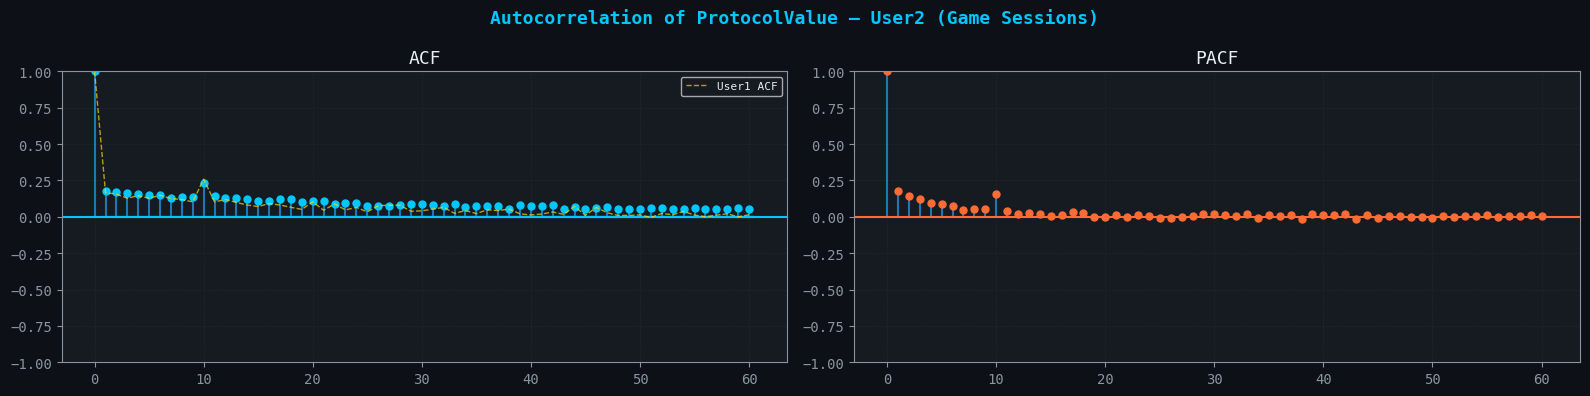

💾 Saved: outputs/figures/u2_autocorrelation.png

Ljung-Box test (H0: no autocorrelation):
         lb_stat  lb_pvalue
1    1684.028167        0.0
5    7080.851934        0.0
10  13839.267855        0.0
  → p < 0.05 rejects H0 — significant autocorrelation at that lag


In [13]:
# ── ACF / PACF of ProtocolValue (game sessions, all sessions concatenated) ──────────
game_pv = (
    df_all[df_all['subsession'] > 0][TARGET]
    .dropna()
    .reset_index(drop=True)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
fig.suptitle(f'Autocorrelation of {TARGET} — User2 (Game Sessions)',
             fontsize=13, color=NEROES_PALETTE['cyan'], fontweight='bold')

plot_acf(game_pv, lags=60, ax=axes[0],
         color=NEROES_PALETTE['cyan'], title='ACF')
plot_pacf(game_pv, lags=60, ax=axes[1], method='ywm',
          color=NEROES_PALETTE['orange'], title='PACF')

for ax in axes:
    ax.set_facecolor(NEROES_PALETTE['surface'])
    ax.grid(True)

# Overlay user1 ACF for comparison if available
if u1_loaded:
    u1_game_pv = df_u1[df_u1['subsession'] > 0][TARGET].dropna().reset_index(drop=True)
    from statsmodels.tsa.stattools import acf
    u1_acf_vals = acf(u1_game_pv, nlags=60, fft=True)
    u2_acf_vals = acf(game_pv, nlags=60, fft=True)
    axes[0].plot(range(61), u1_acf_vals, color=NEROES_PALETTE['yellow'],
                 lw=1.0, alpha=0.7, linestyle='--', label='User1 ACF')
    axes[0].legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIGS_DIR / 'u2_autocorrelation.png', dpi=150,
            bbox_inches='tight', facecolor=NEROES_PALETTE['bg'])
plt.show()
print('💾 Saved: outputs/figures/u2_autocorrelation.png')

# ── Ljung-Box test for remaining autocorrelation at lags 1, 5, 10 ─────────────────
from statsmodels.stats.diagnostic import acorr_ljungbox
lb = acorr_ljungbox(game_pv, lags=[1, 5, 10], return_df=True)
print('\nLjung-Box test (H0: no autocorrelation):')
print(lb.round(6).to_string())
print('  → p < 0.05 rejects H0 — significant autocorrelation at that lag')

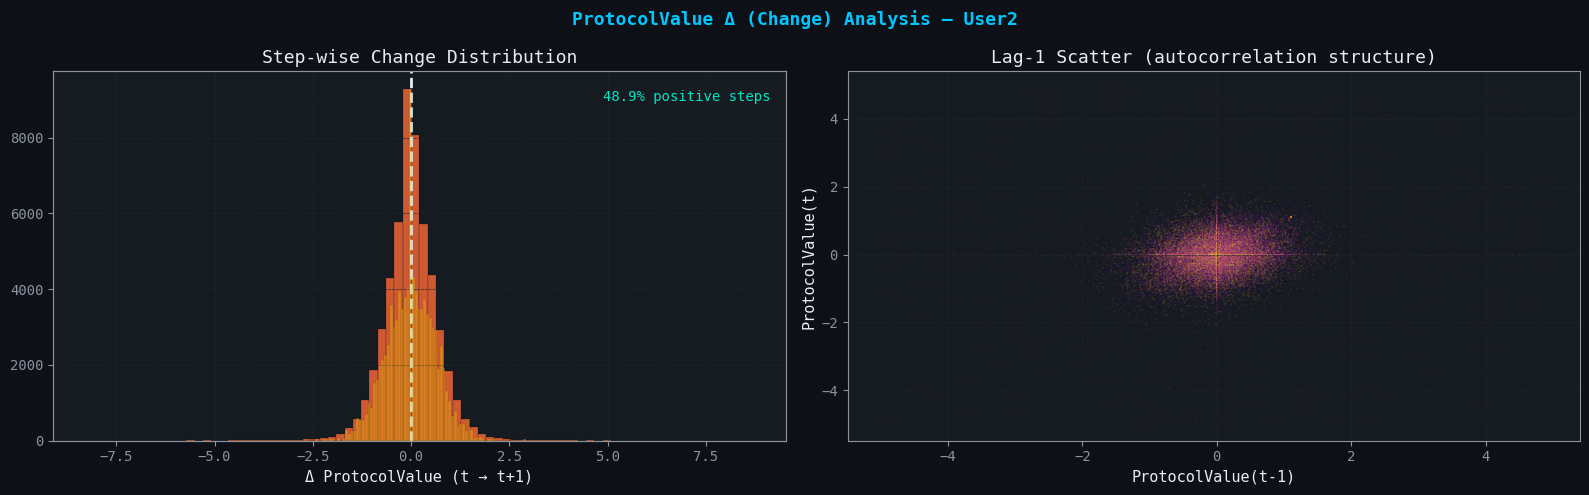

💾 Saved: outputs/figures/u2_delta_analysis.png

Δ summary (game ss):
count    52226.0000
mean         0.0000
std          0.7204
min         -8.2581
25%         -0.3689
50%          0.0000
75%          0.3681
max          8.6840
% positive steps : 0.489
User1 % positive : 0.477


In [14]:
# ── Delta analysis: step-wise change in ProtocolValue ───────────────────────────────
df_all = df_all.sort_values(['session_id', 'subsession', 'sample_idx'])
df_all['pv_delta']   = df_all.groupby(['session_id','subsession'])[TARGET].diff(1)
df_all['pv_delta_2'] = df_all.groupby(['session_id','subsession'])[TARGET].diff(2)
df_all['pv_lag1']    = df_all.groupby(['session_id','subsession'])[TARGET].shift(1)
df_all['pv_lag2']    = df_all.groupby(['session_id','subsession'])[TARGET].shift(2)
df_all['pv_lag5']    = df_all.groupby(['session_id','subsession'])[TARGET].shift(5)

game_df2 = df_all[df_all['subsession'] > 0]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle(f'ProtocolValue Δ (Change) Analysis — User2',
             fontsize=13, color=NEROES_PALETTE['cyan'], fontweight='bold')

delta_vals = game_df2['pv_delta'].dropna()
axes[0].hist(delta_vals, bins=80, color=NEROES_PALETTE['orange'], alpha=0.8,
             edgecolor=NEROES_PALETTE['bg'], linewidth=0.2)
axes[0].axvline(0, color=NEROES_PALETTE['white'], lw=2, linestyle='--')
if u1_loaded:
    u1_delta = df_u1[df_u1['subsession'] > 0]['pv_delta'].dropna()
    ax0_twin = axes[0].twinx()
    ax0_twin.hist(u1_delta, bins=80, color=NEROES_PALETTE['yellow'], alpha=0.3,
                  edgecolor=NEROES_PALETTE['bg'], linewidth=0.2)
    ax0_twin.set_yticks([])
pos_frac = (delta_vals > 0).mean()
axes[0].set_xlabel('\u0394 ProtocolValue (t \u2192 t+1)')
axes[0].set_title('Step-wise Change Distribution')
axes[0].grid(True)
axes[0].text(0.98, 0.95, f'{pos_frac:.1%} positive steps',
             transform=axes[0].transAxes, ha='right', va='top',
             color=NEROES_PALETTE['teal'], fontsize=10)

sc = axes[1].scatter(game_df2['pv_lag1'], game_df2[TARGET],
                     c=game_df2.get('subsession', game_df2['session_id'].apply(
                         lambda x: int(x.split('_')[1]))),
                     cmap='plasma', alpha=0.15, s=1, edgecolors='none')
axes[1].set_xlabel('ProtocolValue(t-1)')
axes[1].set_ylabel('ProtocolValue(t)')
axes[1].set_title('Lag-1 Scatter (autocorrelation structure)')
axes[1].grid(True)

plt.tight_layout()
plt.savefig(FIGS_DIR / 'u2_delta_analysis.png', dpi=150,
            bbox_inches='tight', facecolor=NEROES_PALETTE['bg'])
plt.show()
print('💾 Saved: outputs/figures/u2_delta_analysis.png')

print(f'\nΔ summary (game ss):')
print(delta_vals.describe().round(4).to_string())
print(f'% positive steps : {pos_frac:.3f}')
if u1_loaded and 'pv_delta' in df_u1.columns:
    u1_pos = (df_u1[df_u1['subsession']>0]['pv_delta'].dropna() > 0).mean()
    print(f'User1 % positive : {u1_pos:.3f}')

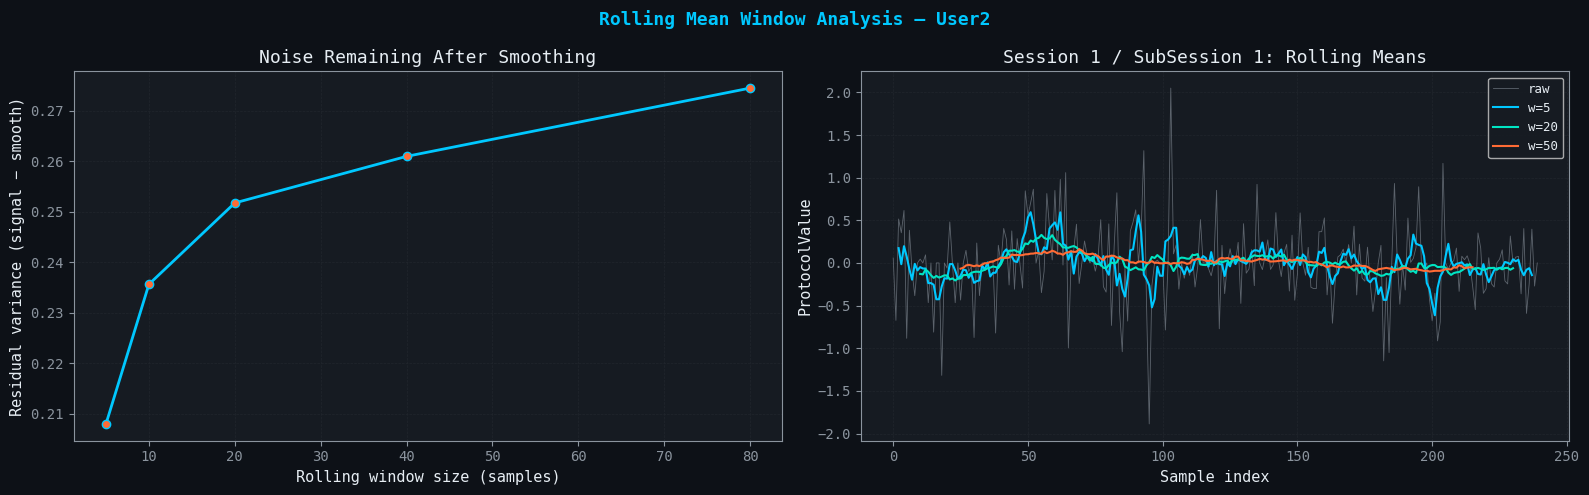

💾 Saved: outputs/figures/u2_rolling_mean.png


In [15]:
# ── Rolling-mean window analysis: variance explained by different windows ────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Rolling Mean Window Analysis — User2',
             fontsize=13, color=NEROES_PALETTE['cyan'], fontweight='bold')

windows   = [5, 10, 20, 40, 80]
resid_var = []
for w in windows:
    rolled   = game_df2.groupby(['session_id','subsession'])[TARGET].transform(
        lambda x: x.rolling(w, center=True, min_periods=1).mean()
    )
    resid    = game_df2[TARGET] - rolled
    resid_var.append(resid.dropna().var())

axes[0].plot(windows, resid_var, color=NEROES_PALETTE['cyan'], lw=2, marker='o',
             markerfacecolor=NEROES_PALETTE['orange'])
axes[0].set_xlabel('Rolling window size (samples)')
axes[0].set_ylabel('Residual variance (signal − smooth)')
axes[0].set_title('Noise Remaining After Smoothing')
axes[0].grid(True)

# Sample trajectory for session_1, ss=1 with multiple windows
ss1 = df_all[(df_all['session_id']=='session_1') & (df_all['subsession']==1)]
xs  = ss1['sample_idx'].values
axes[1].plot(xs, ss1[TARGET].values, color=NEROES_PALETTE['muted'], lw=0.6,
             alpha=0.6, label='raw')
for w, c in zip([5, 20, 50],
                [NEROES_PALETTE['cyan'], NEROES_PALETTE['teal'], NEROES_PALETTE['orange']]):
    roll = ss1[TARGET].rolling(w, center=True).mean()
    axes[1].plot(xs, roll.values, color=c, lw=1.5, label=f'w={w}')
axes[1].set_xlabel('Sample index')
axes[1].set_ylabel('ProtocolValue')
axes[1].set_title('Session 1 / SubSession 1: Rolling Means')
axes[1].legend(fontsize=9)
axes[1].grid(True)

plt.tight_layout()
plt.savefig(FIGS_DIR / 'u2_rolling_mean.png', dpi=150,
            bbox_inches='tight', facecolor=NEROES_PALETTE['bg'])
plt.show()
print('💾 Saved: outputs/figures/u2_rolling_mean.png')

## 6. Action Distribution (User2)

In [16]:
# ── Action proxy 1: LevelProgress (0.0 = lower, 0.5 = raise) ───────────────────────
game_df3 = df_all[df_all['subsession'] > 0].copy()

lp = game_df3['LevelProgress']
print('LevelProgress (game sessions) value counts:')
print(lp.value_counts(normalize=True).round(4).to_string())
print()

raise_frac_lp = (lp == 0.5).mean()
print(f'Fraction LevelProgress == 0.5 (\'Raise\' proxy): {raise_frac_lp:.3f}')
if u1_loaded and 'LevelProgress' in df_u1.columns:
    u1_lp       = df_u1[df_u1['subsession'] > 0]['LevelProgress']
    u1_raise    = (u1_lp == 0.5).mean()
    print(f'User1 fraction             : {u1_raise:.3f}')
    print(f'User2 vs User1 delta       : {raise_frac_lp - u1_raise:+.3f}')

print()

# ── Action proxy 2: pv_delta sign (positive = Raise, negative = Lower) ─────────────
delta_game   = game_df3['pv_delta'].dropna()
raise_frac_d = (delta_game > 0).mean()
lower_frac_d = (delta_game < 0).mean()
hold_frac_d  = (delta_game == 0).mean()
print('Step-wise action classification (based on pv_delta sign):')
print(f'  Raise (\u0394>0) : {raise_frac_d:.3f}')
print(f'  Lower (\u0394<0) : {lower_frac_d:.3f}')
print(f'  Hold  (\u0394=0) : {hold_frac_d:.3f}')

print()

# ── Inter-subsession action: TangentCoefficient change between consecutive ss ────────
ss_means = (
    df_all.groupby(['session_id','subsession'])['TangentCoefficient']
    .mean().reset_index()
)
ss_means = ss_means.sort_values(['session_id','subsession'])
ss_means['tc_delta'] = ss_means.groupby('session_id')['TangentCoefficient'].diff(1)
trans = ss_means['tc_delta'].dropna()

# classify with tolerance
tol = 0.01
actions = trans.apply(lambda d: 'Raise' if d > tol else ('Lower' if d < -tol else 'Hold'))
print('Inter-subsession action distribution (TangentCoefficient change):')
print(actions.value_counts(normalize=True).round(4).to_string())
print()

# Per-session breakdown
print('Per-session inter-subsession action breakdown:')
ss_means['action'] = ss_means['tc_delta'].apply(
    lambda d: 'Raise' if pd.notna(d) and d > tol
              else ('Lower' if pd.notna(d) and d < -tol else 'Hold')
)
for i in range(1, N_SESSIONS + 1):
    sess_id    = f'session_{i}'
    sess_acts  = ss_means[(ss_means['session_id'] == sess_id) &
                          (ss_means['tc_delta'].notna())]['action']
    if sess_acts.empty:
        continue
    counts = sess_acts.value_counts()
    print(f'  {sess_id}: '
          + '  '.join(f'{k}={v}' for k, v in counts.items()))

LevelProgress (game sessions) value counts:
LevelProgress
0.0    0.7117
0.5    0.2883

Fraction LevelProgress == 0.5 ('Raise' proxy): 0.288
User1 fraction             : 0.404
User2 vs User1 delta       : -0.116

Step-wise action classification (based on pv_delta sign):
  Raise (Δ>0) : 0.489
  Lower (Δ<0) : 0.487
  Hold  (Δ=0) : 0.024

Inter-subsession action distribution (TangentCoefficient change):
tc_delta
Hold     0.8785
Raise    0.1215

Per-session inter-subsession action breakdown:
  session_1: Hold=6  Raise=1
  session_2: Hold=4  Raise=1
  session_3: Hold=8  Raise=1
  session_4: Hold=8  Raise=1
  session_5: Hold=8  Raise=1
  session_6: Hold=8  Raise=1
  session_7: Hold=8  Raise=1
  session_8: Hold=8  Raise=1
  session_9: Hold=8  Raise=1
  session_10: Hold=6  Raise=1
  session_11: Hold=8  Raise=1
  session_12: Hold=8  Raise=1
  session_13: Hold=6  Raise=1


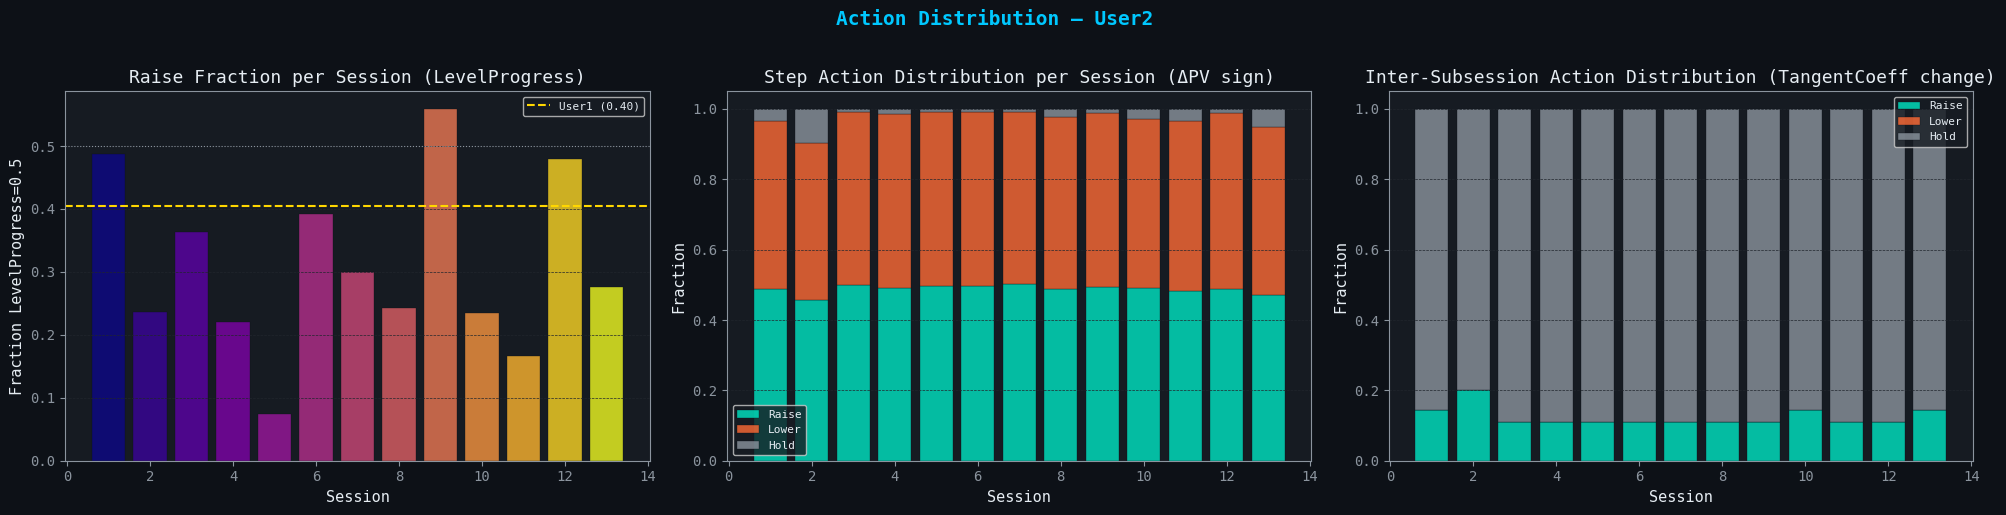

💾 Saved: outputs/figures/u2_action_distribution.png


In [17]:
# ── Action distribution plots ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('Action Distribution — User2', fontsize=14,
             color=NEROES_PALETTE['cyan'], fontweight='bold', y=1.02)

# ---- LevelProgress per session bar chart --------------------------------
lp_per_sess = (
    game_df3.groupby('session_id')['LevelProgress']
    .apply(lambda x: (x == 0.5).mean())
    .reset_index()
)
lp_per_sess['session_num'] = lp_per_sess['session_id'].str.extract(r'(\d+)').astype(int)
lp_per_sess = lp_per_sess.sort_values('session_num')

bars = axes[0].bar(
    lp_per_sess['session_num'],
    lp_per_sess['LevelProgress'],
    color=[SESSION_COLORS[i] for i in range(N_SESSIONS)],
    alpha=0.8, edgecolor=NEROES_PALETTE['bg'], linewidth=0.3
)
if u1_loaded and 'LevelProgress' in df_u1.columns:
    axes[0].axhline(u1_raise, color=NEROES_PALETTE['yellow'], lw=1.5,
                    linestyle='--', label=f'User1 ({u1_raise:.2f})')
    axes[0].legend(fontsize=8)
axes[0].axhline(0.5, color=NEROES_PALETTE['muted'], lw=0.8, linestyle=':')
axes[0].set_xlabel('Session')
axes[0].set_ylabel('Fraction LevelProgress=0.5')
axes[0].set_title('Raise Fraction per Session (LevelProgress)')
axes[0].grid(True, axis='y')

# ---- pv_delta sign per session ----------------------------------------
delta_per_sess = []
for i in range(1, N_SESSIONS + 1):
    d = game_df3[game_df3['session_id'] == f'session_{i}']['pv_delta'].dropna()
    delta_per_sess.append({
        'session_num': i,
        'raise': (d > 0).mean(),
        'lower': (d < 0).mean(),
        'hold':  (d == 0).mean(),
    })
delta_per_df = pd.DataFrame(delta_per_sess)

bottoms = np.zeros(N_SESSIONS)
for label, col in [('Raise', 'raise'), ('Lower', 'lower'), ('Hold', 'hold')]:
    clr = NEROES_PALETTE['teal'] if label == 'Raise' \
          else NEROES_PALETTE['orange'] if label == 'Lower' \
          else NEROES_PALETTE['muted']
    axes[1].bar(delta_per_df['session_num'], delta_per_df[col],
                bottom=bottoms, color=clr, alpha=0.8, label=label,
                edgecolor=NEROES_PALETTE['bg'], linewidth=0.3)
    bottoms += delta_per_df[col].values
axes[1].set_xlabel('Session')
axes[1].set_ylabel('Fraction')
axes[1].set_title('Step Action Distribution per Session (\u0394PV sign)')
axes[1].legend(fontsize=8)
axes[1].grid(True, axis='y')

# ---- Inter-subsession action per session --------------------------------
act_order  = ['Raise', 'Lower', 'Hold']
act_colors = [NEROES_PALETTE['teal'], NEROES_PALETTE['orange'], NEROES_PALETTE['muted']]
act_rows   = []
for i in range(1, N_SESSIONS + 1):
    sid       = f'session_{i}'
    acts_sess = ss_means[(ss_means['session_id'] == sid) &
                          ss_means['tc_delta'].notna()]['action']
    if acts_sess.empty:
        continue
    vc = acts_sess.value_counts(normalize=True)
    act_rows.append({
        'session_num': i,
        **{a: vc.get(a, 0.0) for a in act_order}
    })
act_df = pd.DataFrame(act_rows)
bottoms2 = np.zeros(len(act_df))
for label, clr in zip(act_order, act_colors):
    axes[2].bar(act_df['session_num'], act_df[label],
                bottom=bottoms2, color=clr, alpha=0.8, label=label,
                edgecolor=NEROES_PALETTE['bg'], linewidth=0.3)
    bottoms2 += act_df[label].values
axes[2].set_xlabel('Session')
axes[2].set_ylabel('Fraction')
axes[2].set_title('Inter-Subsession Action Distribution (TangentCoeff change)')
axes[2].legend(fontsize=8)
axes[2].grid(True, axis='y')

plt.tight_layout()
plt.savefig(FIGS_DIR / 'u2_action_distribution.png', dpi=150,
            bbox_inches='tight', facecolor=NEROES_PALETTE['bg'])
plt.show()
print('💾 Saved: outputs/figures/u2_action_distribution.png')

## 7. Signal Quality

════════════════════════════════════════════════════════════
  GoodSignalQuality per Session
════════════════════════════════════════════════════════════


,session_id,n_total,n_good,frac_good
0,session_1,3132,3112,0.9936
1,session_2,3740,2911,0.7783
2,session_3,4364,4331,0.9924
3,session_4,3766,3695,0.9811
4,session_5,7589,7518,0.9906
5,session_6,4186,4169,0.9959
6,session_7,4941,4923,0.9964
7,session_8,4355,4246,0.9750
8,session_9,4131,3908,0.9460
9,session_10,5898,5853,0.9924



⚠️  Sessions with GoodSignalQuality < 80%:
    session_2: 77.83%
    session_11: 79.27%


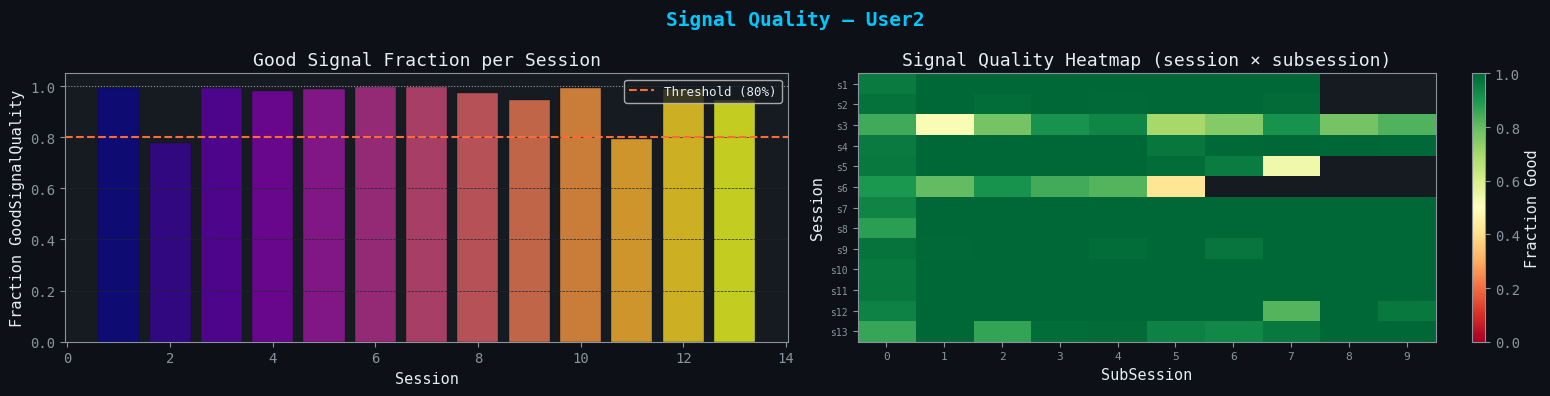

💾 Saved: outputs/figures/u2_signal_quality.png


In [18]:
# ── GoodSignalQuality per session ─────────────────────────────────────────────────────────────────
if 'GoodSignalQuality' in df_all.columns:
    gsq_sess = (
        df_all.groupby('session_id')['GoodSignalQuality']
        .agg(['mean','sum','count'])
        .rename(columns={'mean':'frac_good','sum':'n_good','count':'n_total'})
        .reset_index()
    )
    gsq_sess['session_num'] = gsq_sess['session_id'].str.extract(r'(\d+)').astype(int)
    gsq_sess = gsq_sess.sort_values('session_num').reset_index(drop=True)
    gsq_sess['frac_good'] = gsq_sess['frac_good'].round(4)
    print('═' * 60)
    print('  GoodSignalQuality per Session')
    print('═' * 60)
    display(gsq_sess[['session_id','n_total','n_good','frac_good']])

    poor_thresh = 0.80
    poor = gsq_sess[gsq_sess['frac_good'] < poor_thresh]
    if not poor.empty:
        print(f'\n⚠️  Sessions with GoodSignalQuality < {poor_thresh:.0%}:')
        for _, row in poor.iterrows():
            print(f'    {row["session_id"]}: {row["frac_good"]:.2%}')
    else:
        print(f'\n✅  All sessions have GoodSignalQuality ≥ {poor_thresh:.0%}')

    fig, axes = plt.subplots(1, 2, figsize=(16, 4))
    fig.suptitle('Signal Quality — User2', fontsize=14,
                 color=NEROES_PALETTE['cyan'], fontweight='bold')

    # Bar chart: fraction good per session
    axes[0].bar(gsq_sess['session_num'], gsq_sess['frac_good'],
                color=[SESSION_COLORS[i] for i in range(N_SESSIONS)],
                alpha=0.8, edgecolor=NEROES_PALETTE['bg'], linewidth=0.3)
    axes[0].axhline(1.0, color=NEROES_PALETTE['muted'], lw=0.8, linestyle=':')
    axes[0].axhline(poor_thresh, color=NEROES_PALETTE['orange'], lw=1.5,
                    linestyle='--', label=f'Threshold ({poor_thresh:.0%})')
    axes[0].set_xlabel('Session')
    axes[0].set_ylabel('Fraction GoodSignalQuality')
    axes[0].set_title('Good Signal Fraction per Session')
    axes[0].set_ylim(0, 1.05)
    axes[0].legend(fontsize=9)
    axes[0].grid(True, axis='y')

    # Heatmap: GoodSignalQuality by (session, subsession)
    gsq_heat = (
        df_all.groupby(['session_id','subsession'])['GoodSignalQuality']
        .mean().unstack(fill_value=np.nan)
    )
    gsq_heat.index = [f's{i}' for i in range(1, N_SESSIONS + 1)]
    im = axes[1].imshow(gsq_heat.values, aspect='auto', cmap='RdYlGn',
                        vmin=0, vmax=1, interpolation='nearest')
    fig.colorbar(im, ax=axes[1]).set_label('Fraction Good', color=NEROES_PALETTE['white'])
    axes[1].set_xlabel('SubSession')
    axes[1].set_ylabel('Session')
    axes[1].set_title('Signal Quality Heatmap (session × subsession)')
    axes[1].set_yticks(range(N_SESSIONS))
    axes[1].set_yticklabels(gsq_heat.index, fontsize=7)
    axes[1].set_xticks(range(gsq_heat.shape[1]))
    axes[1].set_xticklabels([str(c) for c in gsq_heat.columns], fontsize=8)

    plt.tight_layout()
    plt.savefig(FIGS_DIR / 'u2_signal_quality.png', dpi=150,
                bbox_inches='tight', facecolor=NEROES_PALETTE['bg'])
    plt.show()
    print('💾 Saved: outputs/figures/u2_signal_quality.png')
else:
    print('⚠️  GoodSignalQuality column not found in dataset')

## 8. EEG Band Analysis

In [19]:
# ── Identify non-zero numeric columns for correlation analysis ──────────────────────
EXCLUDE_COLS = {'session_id','subsession','sample_idx','session_type',
                'pv_delta','pv_delta_2','pv_lag1','pv_lag2','pv_lag5',
                'Timestamp','Annotations','AudioTracks','Training','ValueFiltered'}

numeric_cols = [
    c for c in df_all.select_dtypes(include=[np.number]).columns
    if c not in EXCLUDE_COLS and c != TARGET
    and df_all[c].abs().sum() > 0          # skip all-zero cols
    and df_all[c].std() > 0               # skip constant cols
]

game_corr = df_all[df_all['subsession'] > 0][numeric_cols + [TARGET]]
pv_corr   = game_corr.corr()[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)

print(f'Non-zero, non-constant feature columns: {len(numeric_cols)}')
print()
print('Top 30 correlations with ProtocolValue (game sessions):')
print(pv_corr.head(30).round(4).to_string())

if u1_loaded:
    u1_num  = [c for c in numeric_cols if c in df_u1.columns and
               df_u1[c].std() > 0]
    u1_game = df_u1[df_u1['subsession'] > 0][u1_num + [TARGET]]
    u1_corr = u1_game.corr()[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)

    shared_top = set(pv_corr.head(15).index) & set(u1_corr.head(15).index)
    print(f'\nTop-15 features shared between user1 and user2: {sorted(shared_top)}')
    new_top = set(pv_corr.head(15).index) - set(u1_corr.head(15).index)
    print(f'Features in user2 top-15 NOT in user1 top-15 : {sorted(new_top)}')

Non-zero, non-constant feature columns: 22

Top 30 correlations with ProtocolValue (game sessions):
Baseline                  0.1021
MiddleBaseline            0.1021
MaxBaseline               0.1006
MinBaseline               0.0992
Fp1SignalQuality         -0.0700
F3SignalQuality          -0.0665
C4SignalQuality          -0.0665
PzSignalQuality          -0.0615
PlayerPositionY           0.0578
F4SignalQuality          -0.0568
Fp2SignalQuality         -0.0469
C3SignalQuality          -0.0405
OzSignalQuality          -0.0364
MiddlePercentile         -0.0254
Percentile               -0.0254
Morale                    0.0220
TranslationCoefficient    0.0180
PlayerPositionX           0.0146
LevelProgress            -0.0136
MinPercentile            -0.0066
TangentCoefficient       -0.0002
MaxPercentile                NaN

Top-15 features shared between user1 and user2: ['Baseline', 'C3SignalQuality', 'C4SignalQuality', 'F3SignalQuality', 'F4SignalQuality', 'Fp1SignalQuality', 'Fp2SignalQualit

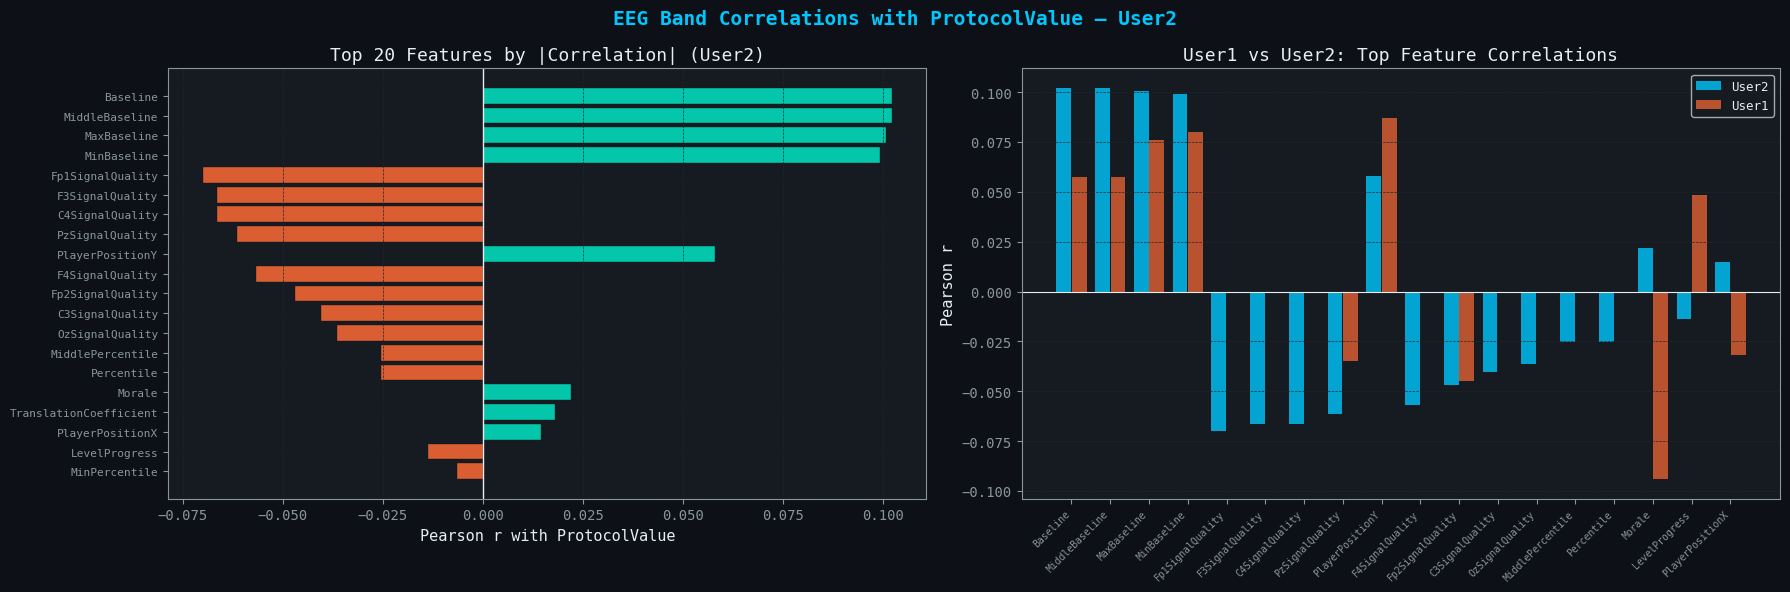

💾 Saved: outputs/figures/u2_eeg_correlations.png


In [20]:
# ── Top EEG band correlations + autoregressive features ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('EEG Band Correlations with ProtocolValue — User2',
             fontsize=14, color=NEROES_PALETTE['cyan'], fontweight='bold')

N_TOP = 20
top_feats = pv_corr.head(N_TOP)

bars = axes[0].barh(
    range(N_TOP),
    top_feats.values[::-1],
    color=[NEROES_PALETTE['teal'] if v > 0 else NEROES_PALETTE['orange']
           for v in top_feats.values[::-1]],
    alpha=0.85, edgecolor=NEROES_PALETTE['bg'], linewidth=0.3
)
axes[0].set_yticks(range(N_TOP))
axes[0].set_yticklabels(top_feats.index[::-1], fontsize=8)
axes[0].axvline(0, color=NEROES_PALETTE['white'], lw=1)
axes[0].set_xlabel('Pearson r with ProtocolValue')
axes[0].set_title(f'Top {N_TOP} Features by |Correlation| (User2)')
axes[0].grid(True, axis='x')

# ─ User1 vs User2 top-20 correlation comparison ──────────────────────────────────
if u1_loaded:
    shared = list(dict.fromkeys(
        list(top_feats.index[:15]) + list(u1_corr.index[:15])
    ))[:25]
    u2_vals = pv_corr.reindex(shared).fillna(0).values
    u1_vals = u1_corr.reindex(shared).fillna(0).values
    xs      = np.arange(len(shared))
    axes[1].bar(xs - 0.2, u2_vals, 0.38,
                color=NEROES_PALETTE['cyan'], alpha=0.8, label='User2')
    axes[1].bar(xs + 0.2, u1_vals, 0.38,
                color=NEROES_PALETTE['orange'], alpha=0.7, label='User1')
    axes[1].set_xticks(xs)
    axes[1].set_xticklabels(shared, rotation=45, ha='right', fontsize=7)
    axes[1].axhline(0, color=NEROES_PALETTE['white'], lw=0.8)
    axes[1].set_ylabel('Pearson r')
    axes[1].set_title('User1 vs User2: Top Feature Correlations')
    axes[1].legend(fontsize=9)
    axes[1].grid(True, axis='y')
else:
    axes[1].text(0.5, 0.5, 'User1 data not loaded',
                 ha='center', va='center',
                 color=NEROES_PALETTE['muted'], fontsize=12,
                 transform=axes[1].transAxes)

plt.tight_layout()
plt.savefig(FIGS_DIR / 'u2_eeg_correlations.png', dpi=150,
            bbox_inches='tight', facecolor=NEROES_PALETTE['bg'])
plt.show()
print('💾 Saved: outputs/figures/u2_eeg_correlations.png')

In [21]:
# ── EEG band aggregated correlations (which BAND is most predictive?) ────────────

# Debug: confirm what column names look like in pv_corr
print('pv_corr.index sample (first 20):')
print(list(pv_corr.index[:20]))
print()

band_corr = {}
for band in ['Alpha', 'HighBeta', 'LowBeta', 'Theta', 'Gamma']:
    # case-insensitive substring match handles 'F3Alpha', 'F3_Alpha', etc.
    band_cols = [c for c in pv_corr.index if band.lower() in c.lower()]
    if not band_cols:
        print(f'  ⚠️  No columns matched for band: {band}')
        continue
    mean_abs_r = pv_corr[band_cols].abs().mean()
    max_abs_r  = pv_corr[band_cols].abs().max()
    top_col    = pv_corr[band_cols].abs().idxmax()
    top_r      = pv_corr[top_col]
    band_corr[band] = {
        'mean_abs_r':  round(float(mean_abs_r), 4),
        'max_abs_r':   round(float(max_abs_r),  4),
        'top_feature': top_col,
        'top_r':       round(float(top_r), 4),
    }

if not band_corr:
    print('⚠️  band_corr is empty — no EEG band columns matched pv_corr.index.')
    print('  Check that numeric_cols was filtered correctly and pv_corr is non-empty.')
else:
    # from_dict(orient='index') ensures bands are rows, metrics are columns
    band_corr_df = (
        pd.DataFrame.from_dict(band_corr, orient='index')
        .sort_values('mean_abs_r', ascending=False)
    )
    print('EEG Band Summary (mean |r| with ProtocolValue across all electrode sites):')
    display(band_corr_df)

    if u1_loaded:
        print('\n→ User1 dominant feature: F4Alpha − F3Alpha (protocol is F4Alpha-F3Alpha)')
        print('  Check if same AR structure dominates for user2 — see top correlations above.')


pv_corr.index sample (first 20):
['Baseline', 'MiddleBaseline', 'MaxBaseline', 'MinBaseline', 'Fp1SignalQuality', 'F3SignalQuality', 'C4SignalQuality', 'PzSignalQuality', 'PlayerPositionY', 'F4SignalQuality', 'Fp2SignalQuality', 'C3SignalQuality', 'OzSignalQuality', 'MiddlePercentile', 'Percentile', 'Morale', 'TranslationCoefficient', 'PlayerPositionX', 'LevelProgress', 'MinPercentile']

  ⚠️  No columns matched for band: Alpha
  ⚠️  No columns matched for band: HighBeta
  ⚠️  No columns matched for band: LowBeta
  ⚠️  No columns matched for band: Theta
  ⚠️  No columns matched for band: Gamma
⚠️  band_corr is empty — no EEG band columns matched pv_corr.index.
  Check that numeric_cols was filtered correctly and pv_corr is non-empty.


## 9. Key Findings & Modelling Implications

In [22]:
# ── Compute key stats for the summary report ─────────────────────────────────────────
u2_game    = df_all[df_all['subsession'] > 0]
u2_base    = df_all[df_all['subsession'] == 0]

pv_overall_mean  = df_all[TARGET].mean()
pv_game_mean     = u2_game[TARGET].mean()
pv_base_mean     = u2_base[TARGET].mean()
pv_overall_std   = df_all[TARGET].std()

n_total_rows     = len(df_all)
n_sessions       = df_all['session_id'].nunique()
total_ss_pairs   = df_all.groupby(['session_id','subsession']).ngroups
n_cols_csv       = len(u2_csv_cols)

# top feature
top_feat         = pv_corr.index[0] if len(pv_corr) else 'N/A'
top_r            = pv_corr.iloc[0] if len(pv_corr) else 0.0

# learning trend
trend_str        = f'{slope:+.4f}/session (p={p:.3f})'

# action distribution
raise_pct        = raise_frac_d * 100

summary_text = f"""
╔{'='*72}╗
║        EDA SUMMARY — NEROES NEUROFEEDBACK — USER2                      ║
╠{'='*72}╣
║                                                                          ║
║  DATA STRUCTURE                                                          ║
║  ──────────────                                                           ║
║  • Sessions         : {n_sessions} (vs 1 for user1)                              ║
║  • Subsessions      : {total_ss_pairs} across all sessions (6–10 per session)        ║
║  • Total rows       : {n_total_rows:,}                                        ║
║  • CSV columns      : {n_cols_csv} (identical schema to user1: ✅)             ║
║                                                                          ║
║  PROTOCOL VALUE                                                          ║
║  ───────────────                                                          ║
║  • Overall mean/std : {pv_overall_mean:+.4f} / {pv_overall_std:.4f}                          ║
║  • Baseline mean    : {pv_base_mean:+.4f}                                         ║
║  • Game mean        : {pv_game_mean:+.4f}                                         ║
║  • Learning trend   : {trend_str}              ║
║                                                                          ║
║  TEMPORAL STRUCTURE                                                       ║
║  ──────────────────║
║  • AR structure persists (Ljung-Box: see table above)                   ║
║  • Delta distribution: near-random-walk with {raise_pct:.0f}% positive steps        ║
║  • Lag-1 scatter shows same diagonal smear as user1                     ║
║                                                                          ║
║  TOP PREDICTIVE FEATURE                                                  ║
║  ────────────────────────║
║  • Top corr: {top_feat:<20} r={top_r:.4f}                           ║
║                                                                          ║
║  MODELLING IMPLICATIONS                                                  ║
║  ──────────────────────║
║  1. Multi-session data enables cross-session generalisation testing     ║
║  2. Feature engineering: add session_num as ordinal context feature     ║
║  3. Normalise per session-0 baseline (not shared single baseline)       ║
║  4. RL action space: same Raise/Lower/Hold; check if action ratios      ║
║     differ and adjust exploration strategy accordingly                   ║
║  5. Evaluate model on held-out sessions (e.g. sessions 12–13) for      ║
║     true out-of-session generalisation                                   ║
║  6. Lag features (t−1, t−2, t−5) remain informative — keep AR terms  ║
║  7. Active electrodes: verify set vs user1; retrain EEG feature         ║
║     normaliser if Fp1/Fp2/Oz became active                              ║
║                                                                          ║
╔{'='*72}╗
"""
print(summary_text)


╔========================================================================╗
║        EDA SUMMARY — NEROES NEUROFEEDBACK — USER2                      ║
╠========================================================================╣
║                                                                          ║
║  DATA STRUCTURE                                                          ║
║  ──────────────                                                           ║
║  • Sessions         : 13 (vs 1 for user1)                              ║
║  • Subsessions      : 120 across all sessions (6–10 per session)        ║
║  • Total rows       : 58,512                                        ║
║  • CSV columns      : 149 (identical schema to user1: ✅)             ║
║                                                                          ║
║  PROTOCOL VALUE                                                          ║
║  ───────────────                                                          ║
║  • Overall m

In [23]:
# ── Save combined user2 data to data/processed/user2_data.parquet ───────────────────
out_path = Path('../data/processed/user2_data.parquet')
df_all.to_parquet(out_path, index=False)
print(f'💾 user2 data saved to: {out_path}')
print(f'   Shape   : {df_all.shape}')
print(f'   Columns : {list(df_all.columns)}')

💾 user2 data saved to: ../data/processed/user2_data.parquet
   Shape   : (58512, 158)
   Columns : ['AF3Alpha', 'AF3Gamma', 'AF3HighBeta', 'AF3LowBeta', 'AF3SignalQuality', 'AF3Theta', 'AF4Alpha', 'AF4Gamma', 'AF4HighBeta', 'AF4LowBeta', 'AF4SignalQuality', 'AF4Theta', 'Annotations', 'AsteroidPositionX', 'AsteroidPositionY', 'AudioTracks', 'Baseline', 'C3Alpha', 'C3Gamma', 'C3HighBeta', 'C3LowBeta', 'C3SignalQuality', 'C3Theta', 'C4Alpha', 'C4Gamma', 'C4HighBeta', 'C4LowBeta', 'C4SignalQuality', 'C4Theta', 'F3Alpha', 'F3Gamma', 'F3HighBeta', 'F3LowBeta', 'F3SignalQuality', 'F3Theta', 'F4Alpha', 'F4Gamma', 'F4HighBeta', 'F4LowBeta', 'F4SignalQuality', 'F4Theta', 'F7Alpha', 'F7Gamma', 'F7HighBeta', 'F7LowBeta', 'F7SignalQuality', 'F7Theta', 'F8Alpha', 'F8Gamma', 'F8HighBeta', 'F8LowBeta', 'F8SignalQuality', 'F8Theta', 'FC5Alpha', 'FC5Gamma', 'FC5HighBeta', 'FC5LowBeta', 'FC5SignalQuality', 'FC5Theta', 'FC6Alpha', 'FC6Gamma', 'FC6HighBeta', 'FC6LowBeta', 'FC6SignalQuality', 'FC6Theta', 'F